# Module 5: FedAvg Baselines

This focused notebook owns the clean FedAvg and attacked FedAvg handoff artifacts for Module 5.


## Stage Goal

Run the same FedAvg server twice: once with no malicious clients and once with the configured Module 4 malicious-client recipe. Save both result JSON files, update diagnostics, and an inline update-norm plot.


## 1. Notebook Setup

Load the split-notebook helper layer and keep imports independent of whether Jupyter starts from the repository root or from `5_Defensive_FL/`.


In [10]:
from pathlib import Path
import sys

import pandas as pd
from IPython.display import Image, display

cwd = Path.cwd()
MODULE_DIR = cwd if cwd.name == "5_Defensive_FL" else cwd / "5_Defensive_FL"
MODULE4_DIR = MODULE_DIR.parent / "4_Adversarial_FL"
MODULE4_SRC_DIR = MODULE4_DIR / "src"
REPO_ROOT = MODULE_DIR.parent

for path in (REPO_ROOT, MODULE4_DIR, MODULE4_SRC_DIR, MODULE_DIR):
    path_str = str(path.resolve())
    if path_str not in sys.path:
        sys.path.insert(0, path_str)

from src.notebook_utils import (
    prepare_context,
    record_config_snapshot,
    run_fedavg_baselines,
    save_update_diagnostics,
    run_result_path,
    validate_artifacts,
    validate_result_collection,
)


## 2. Configuration

Edit this visible `CONFIG` cell to change data, FL, attack, handoff, or artifact settings. No YAML file is required for the focused notebook path.


In [11]:
CONFIG = {'data_config': {'dataset_path': './Data/Imagenette',
                 'dataset_name': 'Imagenette',
                 'non_iid_per': 0,
                 'eval_subset': 'attack_eval',
                 'validation_split': {'enabled': True, 'seed': 42, 'selection_fraction': 0.5}},
 'global_config': {'seed': 42, 'device': 'cuda'},
 'module4_handoff': {'enabled': True,
                     'artifacts_dir': '../4_Adversarial_FL/artifacts',
                     'target_checkpoint': 'module4_v3_target.pt',
                     'surrogate_checkpoint': 'module4_surrogate.pt'},
 'artifacts': {'dir': 'artifacts',
               'config_snapshot': 'module5_baselines_config_used.json',
               'clean_baseline_metrics': 'module5_clean_fedavg.json',
               'attacked_baseline_metrics': 'module5_attacked_fedavg.json',
               'update_diagnostics': 'module5_update_diagnostics.json',
               'update_norm_plot': 'module5_update_norms.png'},
 'stage': {'name': 'fedavg_baselines', 'notebook': 'fedavg_baselines.ipynb'},
 'model_config': {'module': 'model',
                  'name': 'MobileNetV3Transfer',
                  'kwargs': {'pretrained': False, 'num_classes': 10, 'dropout': 0.1}},
 'algorithms': {'FedAvg': {'fed_config': {'algorithm': 'FedAvg',
                                          'fraction_clients': 0.2,
                                          'num_clients': 100,
                                          'num_rounds': 30,
                                          'num_epochs': 5,
                                          'batch_size': 64,
                                          'global_stepsize': 1.0,
                                          'local_stepsize': 0.002,
                                          'criterion': 'torch.nn.CrossEntropyLoss'},
                           'optim_config': {}}},
 'defense': {'name': 'fedavg'},
 'attack': {'seed': 42,
            'malicious_fraction': 0.2,
            'malicious_client_selection': {'mode': 'seeded_random', 'client_ids': []},
            'start_round': 1,
            'attack': {'type': 'pgd',
                       'poison_rate': 0.4,
                       'target_label': 0,
                       'epsilon': 8 / 255,
                       'step_size': 2 / 255,
                       'iters': 30,
                       'criterion': 'torch.nn.CrossEntropyLoss',
                       'poison_rate_schedule': None},
                       # 'poison_rate_schedule': {'type': 'linear', 'start': 0.00, 'end': 0.0}},
            'surrogate': {'checkpoint': '../4_Adversarial_FL/artifacts/module4_surrogate.pt',
                          'checkpoint_source': 'train_surrogate.ipynb',
                          'pretrained': False,
                          'finetune_epochs': 0,
                          'local_finetune_epochs': 0,
                          'learning_rate': 0.001,
                          'weight_decay': 0.0,
                          'batch_size': 64,
                          'freeze_backbone': False,
                          'early_stop_patience': 0}}}

context = prepare_context(CONFIG, stage_name="fedavg_baselines")
config_snapshot_path = record_config_snapshot(context)
config_snapshot_path


Loaded notebook cell: stage=fedavg_baselines, rounds=30, sampled_clients=20, eval_subset=attack_eval.


PosixPath('/home/ahoop004/T3-Ciders-FL/5_Defensive_FL/artifacts/module5_baselines_config_used.json')

## 3. Clean and Attacked FedAvg

The clean run sets malicious fraction and poison rate to zero. The attacked run uses the configured PGD malicious-client recipe.


In [12]:
run_results = run_fedavg_baselines(context)
baseline_validation = validate_result_collection(
    context,
    run_results,
    required_runs=["clean_fedavg", "attacked_fedavg"],
)
validate_artifacts(run_result_path(context, name) for name in run_results)
display(pd.DataFrame(baseline_validation))


Defensive server initialized
Clients successfully initialised
Initialized defensive server from /home/ahoop004/T3-Ciders-FL/4_Adversarial_FL/artifacts/module4_v3_target.pt

Communication Round: 1



Preparing data with Dirichlet partitioner (aligned with Module 2)
Loading cached client data from cache/client_data_7aefb7fbe94af4a610cf3e5bf7789b72.pkl
[FedAvgDefenseServer] Round 1/30 selected 20 clients, 5 local epoch(s), defense=fedavg


	client_update completed
	server_update completed
	Loss: 0.0767   Accuracy: 97.66%

Communication Round: 2


	Server Loss: 0.0767   Accuracy: 97.66%
[FedAvgDefenseServer] Round 2/30 selected 20 clients, 5 local epoch(s), defense=fedavg


	client_update completed
	server_update completed
	Loss: 0.0768   Accuracy: 97.66%

Communication Round: 3


...

	client_update completed
	server_update completed
	Loss: 0.1036   Accuracy: 96.89%

Communication Round: 30


	Server Loss: 0.1036   Accuracy: 96.89%
[FedAvgDefenseServer] Round 30/30 selected 20 clients, 5 local epoch(s), defense=fedavg


	client_update completed
	server_update completed
	Loss: 0.1271   Accuracy: 96.28%

Execution has completed


	Server Loss: 0.1271   Accuracy: 96.28%


,run,rounds,final_accuracy,final_surrogate_poison_success_rate,final_global_target_label_asr
0,clean_fedavg,30,97.757390,0.0,0.226116
1,attacked_fedavg,30,96.279307,100.0,1.074053


## 4. Update Diagnostics

Use the attacked FedAvg run to record client update norms, malicious-client flags, cosine-to-mean behavior, and distance to the coordinate-wise median.


,round,client_id,is_malicious,update_norm,cosine_to_mean,distance_to_coordinate_median
0,1,0,False,0.003728,-0.042798,0.004224
1,1,4,False,0.010219,-0.002666,0.010247
2,1,10,False,0.006560,0.025101,0.006484
3,1,12,True,0.115127,0.867002,0.114421
4,1,18,False,0.005792,0.004391,0.005933


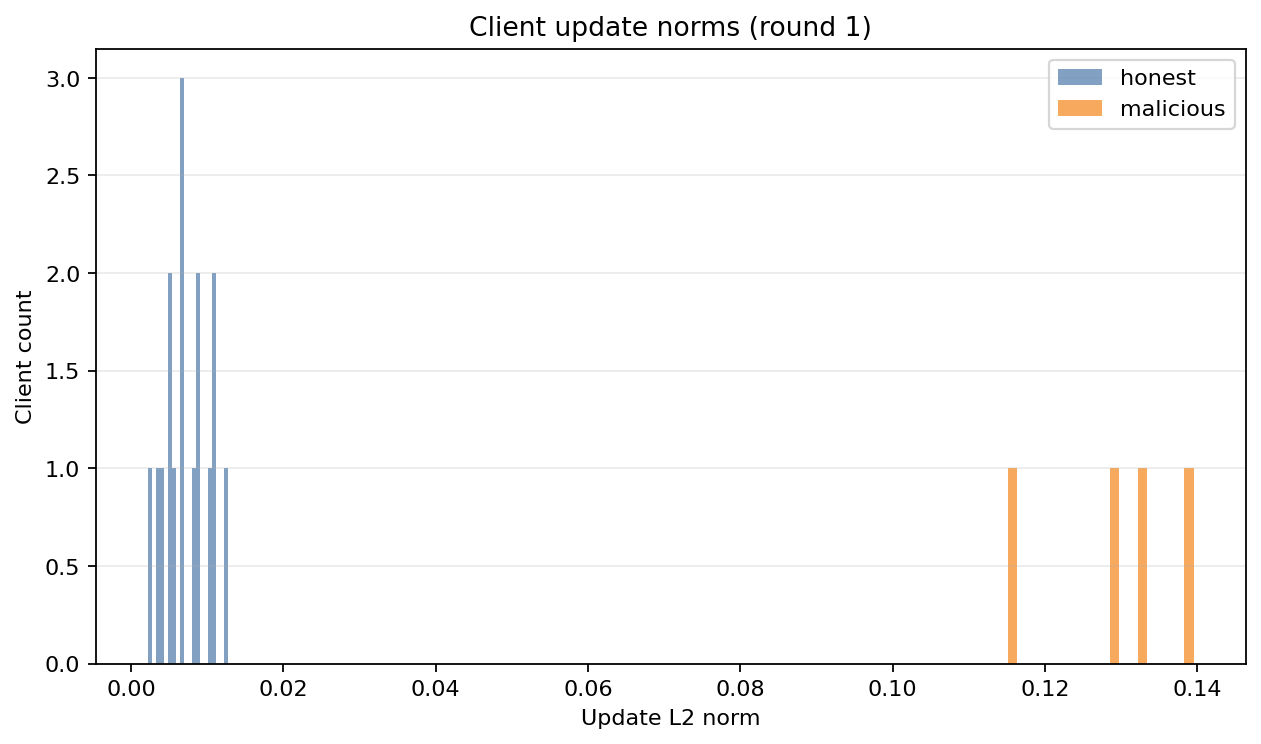

In [13]:
norm_rows = save_update_diagnostics(context, run_results["attacked_fedavg"])
validate_artifacts([
    context.artifact_path("module5_update_diagnostics.json"),
    context.artifact_path("module5_update_norms.png"),
])
display(pd.DataFrame(norm_rows).head())
display(Image(filename=str(context.artifact_path("module5_update_norms.png"))))


## Handoff Artifacts

Run one or more `*_defense.ipynb` notebooks after these files exist.


In [14]:
handoff_artifacts = validate_artifacts([
    config_snapshot_path,
    context.artifact_path("module5_clean_fedavg.json"),
    context.artifact_path("module5_attacked_fedavg.json"),
    context.artifact_path("module5_update_diagnostics.json"),
    context.artifact_path("module5_update_norms.png"),
])
handoff_artifacts


['module5_baselines_config_used.json',
 'module5_clean_fedavg.json',
 'module5_attacked_fedavg.json',
 'module5_update_diagnostics.json',
 'module5_update_norms.png']